Carregando resultados DRI vs Random de: D:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\data_splits_cache\dri_vs_random_final_log_results.csv
Dados DRI vs Random carregados. Shape: (12, 8)
Tamanhos de L0 com resultados AG encontrados: [10, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000, 30000]
L0 Sizes para comparação com AG (interseção ou fallback): [10, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000, 30000]


Coletando dados do AG Envelope:   0%|          | 0/11 [00:00<?, ?it/s]


Dados do Envelope AG coletados:


,l0_size,AG_Acc_Max_Line,AG_Acc_Min_Line,AG_Acc_Envelope_Lower,AG_Acc_Envelope_Upper,AG_F1_Max_Line,AG_F1_Min_Line,AG_F1_Envelope_Lower,AG_F1_Envelope_Upper
0,10,0.194488,0.000759,0.000759,0.194488,NaN,0.000053,0.000053,NaN
1,50,0.332126,0.017827,0.017827,0.332126,0.036857,0.003739,0.003739,0.036857
2,100,0.387645,0.057502,0.057502,0.387645,0.065053,0.018091,0.018091,0.065053
3,250,0.377939,0.360405,0.360405,0.377939,0.071056,NaN,NaN,0.071056
4,500,0.560046,0.361676,0.361676,0.560046,0.180118,0.065241,0.065241,0.180118


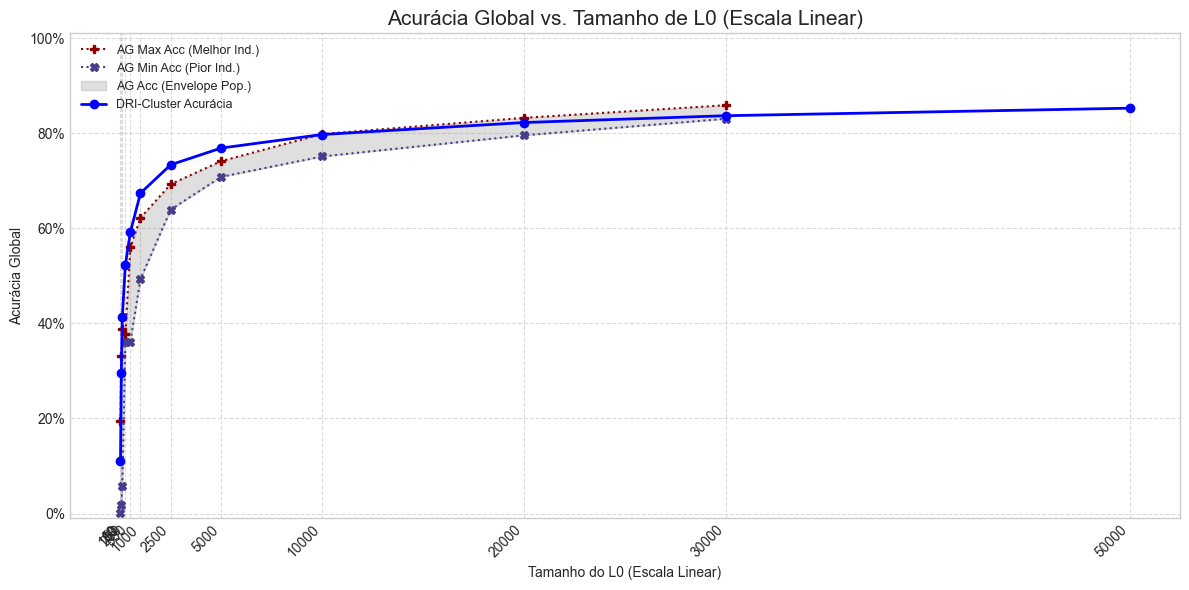

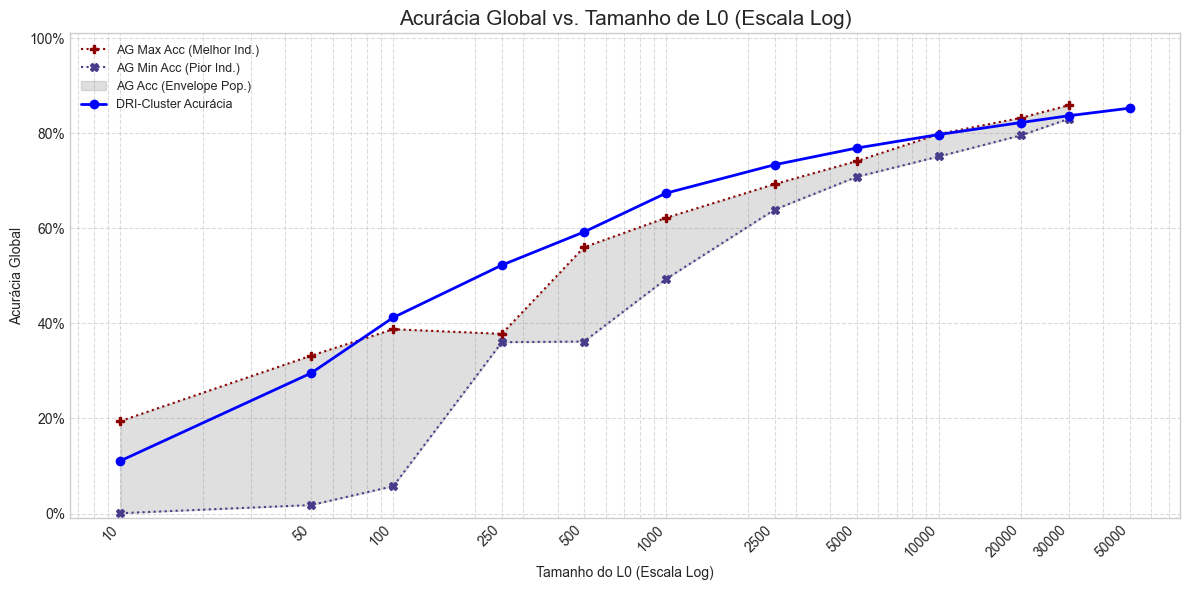

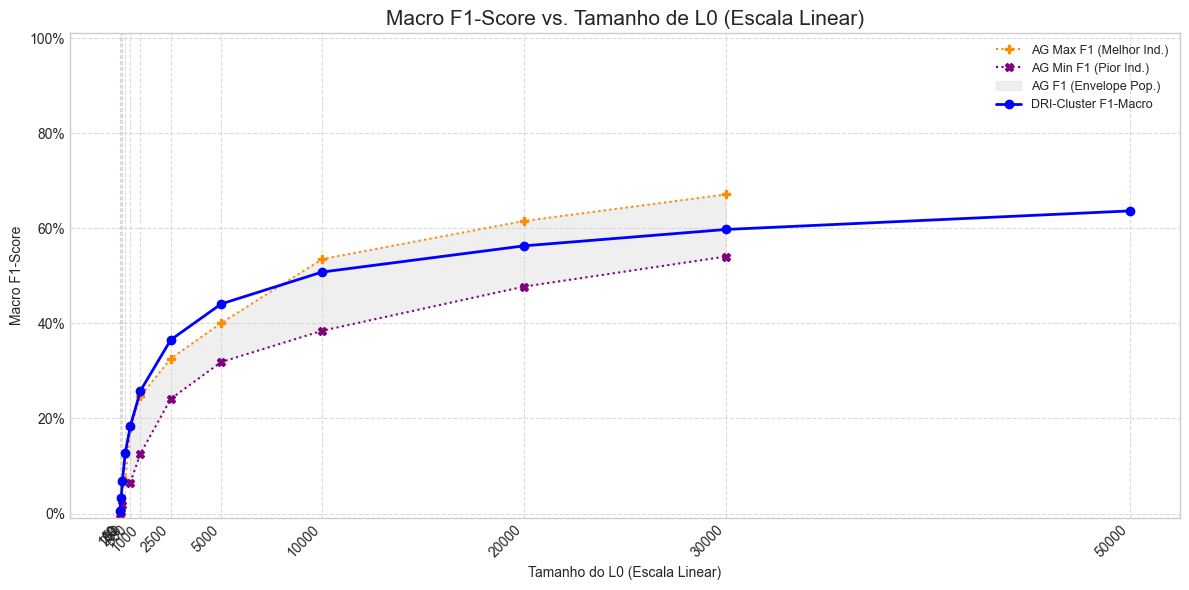

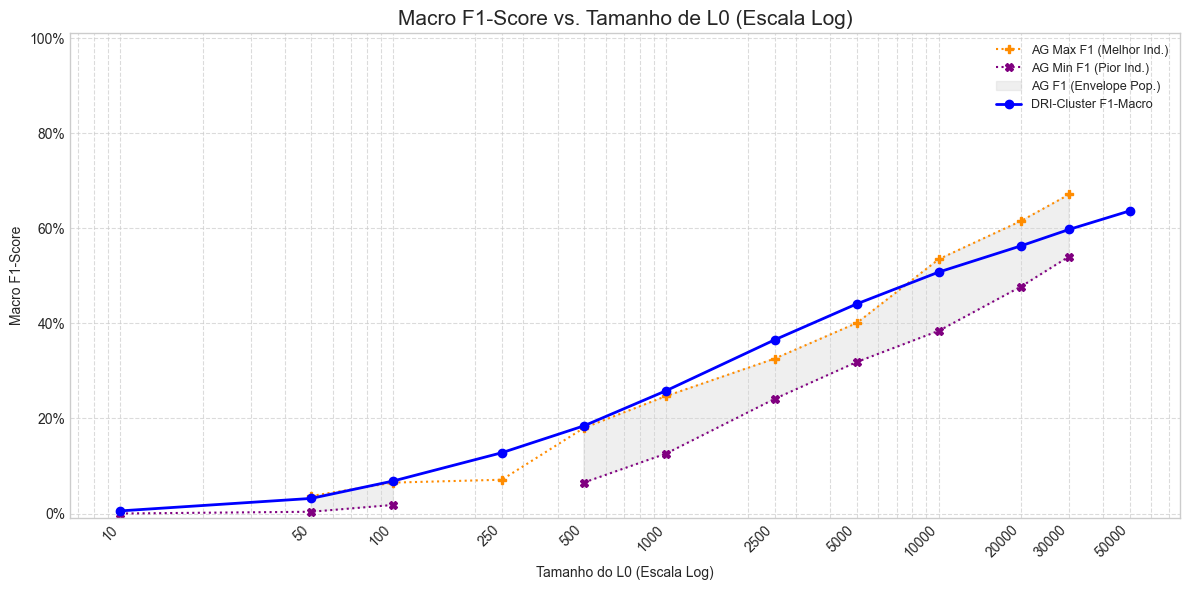


--- Tabela Sumarizada de Performance (DRI, Aleatório e Linhas AG Min/Max) ---


,L0 Size,DRI Acc.,DRI F1,Rand Acc.,Rand F1,AG Acc (Pior),AG Acc (Melhor),AG F1 (Pior),AG F1 (Melhor)
0,10,11.09%,0.56%,-,-,0.08%,19.45%,0.01%,-
1,50,29.54%,3.18%,-,-,1.78%,33.21%,0.37%,3.69%
2,100,41.23%,6.85%,-,-,5.75%,38.76%,1.81%,6.51%
3,250,52.25%,12.79%,-,-,36.04%,37.79%,-,7.11%
4,500,59.22%,18.45%,-,-,36.17%,56.00%,6.52%,18.01%
5,1000,67.39%,25.83%,-,-,49.33%,62.20%,12.60%,24.69%
6,2500,73.36%,36.53%,-,-,63.92%,69.28%,24.11%,32.58%
7,5000,76.87%,44.09%,-,-,70.82%,74.13%,31.87%,40.07%
8,10000,79.72%,50.79%,-,-,75.10%,79.82%,38.44%,53.50%
9,20000,82.24%,56.30%,-,-,79.55%,83.23%,47.73%,61.53%


In [6]:
# %% [markdown]
# # Análise Comparativa de Estratégias de Cold Start: DRI-Cluster vs. Aleatório vs. Envelope AG
#
# Este notebook analisa e visualiza os resultados de desempenho das estratégias de
# cold start DRI-Cluster e Amostragem Aleatória, comparando-os com o envelope de
# performance (mínimo e máximo) obtido por otimizações via Algoritmo Genético (AG)
# para diferentes tamanhos de L0.

# %% [markdown]
# ## 1. Configurações e Imports

# %%
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
import glob 

# Adicionar o diretório pai ao sys.path para importar o módulo da biblioteca, se necessário
# module_path = os.path.abspath(os.path.join('..'))
# if module_path not in sys.path:
#     sys.path.append(module_path)

# Tentar importar funções de plotagem/análise do AG se existirem em um módulo
# try:
#     from activetextclassification.visualization.ag_plots_evolution import (
#         load_and_aggregate_detailed_log, # Exemplo de nome de função
#         get_ag_last_gen_performance_and_range # Exemplo de nome de função
#     )
#     print("Funções de análise do AG importadas de activetextclassification.visualization.ag_plots_evolution")
# except ImportError:
#     print("AVISO: Funções de análise do AG não encontradas em módulo. Serão definidas localmente.")
    # As funções serão definidas na Seção 2.2 se não puderem ser importadas.


plt.style.use('seaborn-v0_8-whitegrid') 
sns.set_palette("husl") 

# --- Caminhos para os Arquivos ---
BASE_DATA_PATH = r"D:\Nuvem\ghdaru\OneDrive\030_DOUTORADO\120_TESE\130_TESEGIT\activetextclassification\data_splits_cache"
DRI_VS_RANDOM_RESULTS_FILE = os.path.join(BASE_DATA_PATH, "dri_vs_random_final_log_results.csv") 

BASE_AG_RESULTS_PATH = r"." 
AG_DETAILED_FITNESS_BASE_NAME = "ag_detailed_fitness" 
MAX_GENERATIONS_TO_PLOT_AG = 100

TEXT_COLUMN = "nm_item" 
LABEL_COLUMN = "nm_product"
RANDOM_SEED = 42 
np.random.seed(RANDOM_SEED)
if hasattr(pd.core.common, 'random_state'): pd.core.common.random_state(RANDOM_SEED)

L0_SIZE_COL = 'l0_size'
STRATEGY_COL = 'strategy'
ACCURACY_COL = 'accuracy'
F1_MACRO_COL = 'f1_macro'
ACCURACY_STD_COL = 'accuracy_std'
F1_MACRO_STD_COL = 'f1_macro_std'

# %% [markdown]
# ## 2. Carregamento e Preparação dos Dados de Resultados

# %% [markdown]
# ### 2.1 Dados do DRI-Cluster e Amostragem Aleatória

# %%
print(f"Carregando resultados DRI vs Random de: {DRI_VS_RANDOM_RESULTS_FILE}")
try:
    df_cold_start_results = pd.read_csv(DRI_VS_RANDOM_RESULTS_FILE)
    print(f"Dados DRI vs Random carregados. Shape: {df_cold_start_results.shape}")
except FileNotFoundError:
    print(f"ERRO: Arquivo '{DRI_VS_RANDOM_RESULTS_FILE}' não encontrado.")
    df_cold_start_results = pd.DataFrame()
except Exception as e:
    print(f"ERRO ao carregar '{DRI_VS_RANDOM_RESULTS_FILE}': {e}")
    df_cold_start_results = pd.DataFrame()

if not df_cold_start_results.empty:
    df_cold_start_results[L0_SIZE_COL] = pd.to_numeric(df_cold_start_results[L0_SIZE_COL], errors='coerce')
    df_cold_start_results = df_cold_start_results.dropna(subset=[L0_SIZE_COL])
    df_plot_dri = df_cold_start_results[df_cold_start_results[STRATEGY_COL] == 'DRI-Cluster'].sort_values(by=L0_SIZE_COL).copy()
    df_plot_random = df_cold_start_results[df_cold_start_results[STRATEGY_COL] == 'Random'].sort_values(by=L0_SIZE_COL).copy()
    if ACCURACY_STD_COL not in df_plot_random.columns: df_plot_random[ACCURACY_STD_COL] = 0.0
    if F1_MACRO_STD_COL not in df_plot_random.columns: df_plot_random[F1_MACRO_STD_COL] = 0.0
    df_plot_random[ACCURACY_STD_COL] = df_plot_random[ACCURACY_STD_COL].fillna(0.0)
    df_plot_random[F1_MACRO_STD_COL] = df_plot_random[F1_MACRO_STD_COL].fillna(0.0)
else:
    df_plot_dri = pd.DataFrame(); df_plot_random = pd.DataFrame()

# %% [markdown]
# ### 2.2 Funções Auxiliares para Carregar Dados do Algoritmo Genético (AG)
# Estas funções são adaptadas do notebook de análise do AG.

# %%
def get_ag_detailed_fitness_filepath_local(l0_size, metric_short, goal_short, base_path, file_base_name):
    dir_path = os.path.join(base_path, f"ag_optimization_results_L0_{l0_size}")
    filename = f"{file_base_name}{metric_short.upper()}_{goal_short.upper()}.csv"
    return os.path.join(dir_path, filename)

def load_and_aggregate_detailed_log_local(l0_size, metric_short_name, goal_short_name, max_gens, base_path, file_base_name):
    filepath = get_ag_detailed_fitness_filepath_local(l0_size, metric_short_name, goal_short_name, base_path, file_base_name)
    metric_col_in_file = 'accuracy_on_full' if metric_short_name.upper() == 'ACCURACY' else 'f1_macro_on_full'
    try:
        df_detailed = pd.read_csv(filepath)
        if max_gens and 'generation' in df_detailed.columns:
            df_detailed = df_detailed[df_detailed['generation'] <= max_gens]
        if df_detailed.empty or metric_col_in_file not in df_detailed.columns: return None
        df_detailed[metric_col_in_file] = pd.to_numeric(df_detailed[metric_col_in_file], errors='coerce')
        df_detailed.dropna(subset=[metric_col_in_file], inplace=True) 
        if df_detailed.empty: return None
        
        grouped = df_detailed.groupby('generation')
        df_agg_perf = grouped[metric_col_in_file].agg(['max', 'mean', 'min']).reset_index()
        df_agg_perf.rename(columns={'max': 'max_metric', 'mean': 'avg_metric', 'min': 'min_metric'}, inplace=True)
        return df_agg_perf
    except FileNotFoundError: return None
    except Exception: return None

def get_ag_last_gen_performance_and_range_local(l0_size, metric_short, goal, base_path, file_base_name, max_gens_plot):
    df_agg = load_and_aggregate_detailed_log_local(l0_size, metric_short, goal, max_gens_plot, base_path, file_base_name)
    if df_agg is not None and not df_agg.empty:
        last_gen_data = df_agg.iloc[-1]
        pop_min_at_last_gen = last_gen_data['min_metric']
        pop_max_at_last_gen = last_gen_data['max_metric']
        line_performance = pop_max_at_last_gen if goal.upper() == "MAXIMIZE" else pop_min_at_last_gen
        return line_performance, pop_min_at_last_gen, pop_max_at_last_gen
    return np.nan, np.nan, np.nan

# %% [markdown]
# ### 2.3 Coleta de Dados do Envelope do AG

# %%
ag_l0_size_folders = glob.glob(os.path.join(BASE_AG_RESULTS_PATH, "ag_optimization_results_L0_*"))
AVAILABLE_L0_SIZES_AG = sorted([int(os.path.basename(f).split('_')[-1]) for f in ag_l0_size_folders if os.path.basename(f).split('_')[-1].isdigit()])
print(f"Tamanhos de L0 com resultados AG encontrados: {AVAILABLE_L0_SIZES_AG}")

df_ag_envelope_data_list = []
# Usar os L0_sizes para os quais temos resultados do DRI/Random e que também têm dados do AG
l0_sizes_for_plot_comparison = sorted(list(set(df_cold_start_results[L0_SIZE_COL].unique()) & set(AVAILABLE_L0_SIZES_AG)))
if not l0_sizes_for_plot_comparison:
     l0_sizes_for_plot_comparison = sorted(list(df_cold_start_results[L0_SIZE_COL].unique())) # Usar os do cold_start se não houver interseção
     print(f"AVISO: Nenhum L0 size em comum com resultados do AG. Usando L0s de cold_start: {l0_sizes_for_plot_comparison}")


print(f"L0 Sizes para comparação com AG (interseção ou fallback): {l0_sizes_for_plot_comparison}")

for l0 in tqdm(l0_sizes_for_plot_comparison, desc="Coletando dados do AG Envelope"):
    # Acurácia
    acc_max_line, acc_env_lower_temp, acc_env_upper_temp = get_ag_last_gen_performance_and_range_local(l0, "ACCURACY", "MAXIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    acc_min_line, _, _ = get_ag_last_gen_performance_and_range_local(l0, "ACCURACY", "MINIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    # Para o envelope, queremos o mínimo da população do cenário MIN e o máximo da população do cenário MAX
    _, ag_acc_envelope_lower, _ = get_ag_last_gen_performance_and_range_local(l0, "ACCURACY", "MINIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    _, _, ag_acc_envelope_upper = get_ag_last_gen_performance_and_range_local(l0, "ACCURACY", "MAXIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)


    # F1-Score
    f1_max_line, f1_env_lower_temp, f1_env_upper_temp = get_ag_last_gen_performance_and_range_local(l0, "F1", "MAXIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    f1_min_line, _, _ = get_ag_last_gen_performance_and_range_local(l0, "F1", "MINIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    _, ag_f1_envelope_lower, _ = get_ag_last_gen_performance_and_range_local(l0, "F1", "MINIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)
    _, _, ag_f1_envelope_upper = get_ag_last_gen_performance_and_range_local(l0, "F1", "MAXIMIZE", BASE_AG_RESULTS_PATH, AG_DETAILED_FITNESS_BASE_NAME, MAX_GENERATIONS_TO_PLOT_AG)


    df_ag_envelope_data_list.append({
        L0_SIZE_COL: l0,
        'AG_Acc_Max_Line': acc_max_line, 
        'AG_Acc_Min_Line': acc_min_line, 
        'AG_Acc_Envelope_Lower': ag_acc_envelope_lower if pd.notna(ag_acc_envelope_lower) else acc_min_line, # Fallback
        'AG_Acc_Envelope_Upper': ag_acc_envelope_upper if pd.notna(ag_acc_envelope_upper) else acc_max_line, # Fallback
        'AG_F1_Max_Line': f1_max_line,
        'AG_F1_Min_Line': f1_min_line,
        'AG_F1_Envelope_Lower': ag_f1_envelope_lower if pd.notna(ag_f1_envelope_lower) else f1_min_line, # Fallback
        'AG_F1_Envelope_Upper': ag_f1_envelope_upper if pd.notna(ag_f1_envelope_upper) else f1_max_line, # Fallback
    })

df_ag_envelope = pd.DataFrame(df_ag_envelope_data_list)
if not df_ag_envelope.empty:
    print("\nDados do Envelope AG coletados:")
    display(df_ag_envelope.head())
else:
    print("\nAVISO: Nenhum dado para o envelope do AG foi coletado.")


# %% [markdown]
# ## 3. Visualização dos Resultados Comparativos
# (Os plots serão ajustados para incluir o envelope do AG)

# %% [markdown]
# ### 3.1 Gráficos de Acurácia Global (Linear e Log)

# %%
if not df_plot_dri.empty or not df_plot_random.empty or not df_ag_envelope.empty:
    plot_l0_ticks = sorted(list(set(df_cold_start_results[L0_SIZE_COL].unique()) | (set(df_ag_envelope[L0_SIZE_COL].unique()) if not df_ag_envelope.empty else set()) ))
    if not plot_l0_ticks: plot_l0_ticks = [100, 1000, 5000] # Default ticks

    for scale_type in ['linear', 'log']:
        plt.figure(figsize=(12, 6))
        
        if not df_ag_envelope.empty:
            plt.plot(df_ag_envelope[L0_SIZE_COL], df_ag_envelope['AG_Acc_Max_Line'], label='AG Max Acc (Melhor Ind.)', color='darkred', marker='P', linestyle=':', zorder=2)
            plt.plot(df_ag_envelope[L0_SIZE_COL], df_ag_envelope['AG_Acc_Min_Line'], label='AG Min Acc (Pior Ind.)', color='darkslateblue', marker='X', linestyle=':', zorder=2)
            plt.fill_between(df_ag_envelope[L0_SIZE_COL], 
                             df_ag_envelope['AG_Acc_Envelope_Lower'].fillna(df_ag_envelope['AG_Acc_Min_Line']), # Preencher NaN se houver
                             df_ag_envelope['AG_Acc_Envelope_Upper'].fillna(df_ag_envelope['AG_Acc_Max_Line']), 
                             color='grey', alpha=0.25, label='AG Acc (Envelope Pop.)', zorder=1)

        if not df_plot_dri.empty:
            plt.plot(df_plot_dri[L0_SIZE_COL], df_plot_dri[ACCURACY_COL], label='DRI-Cluster Acurácia', marker='o', linestyle='-', color='blue', zorder=4, linewidth=2)
        if not df_plot_random.empty:
            plt.plot(df_plot_random[L0_SIZE_COL], df_plot_random[ACCURACY_COL], label='Aleatório Acurácia', marker='s', linestyle='--', color='green', zorder=3, linewidth=1.5)

        plt.title(f'Acurácia Global vs. Tamanho de L0 (Escala {scale_type.capitalize()})', fontsize=15)
        plt.xlabel(f'Tamanho do L0 (Escala {scale_type.capitalize()})')
        plt.ylabel('Acurácia Global')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, which="both", ls="--", alpha=0.7)
        plt.ylim(bottom=-0.01, top=1.01)
        plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
        
        if scale_type == 'log': plt.xscale('log')
        plt.xticks(plot_l0_ticks, labels=[str(int(s)) for s in plot_l0_ticks], rotation=45, ha="right")
        if scale_type == 'log': plt.gca().get_xaxis().set_minor_formatter(mticker.NullFormatter())
        
        plt.tight_layout()
        plt.show()
else:
    print("Dados insuficientes para plotar gráficos de Acurácia.")


# %% [markdown]
# ### 3.2 Gráficos de Macro F1-Score (Linear e Log)

# %%
if not df_plot_dri.empty or not df_plot_random.empty or not df_ag_envelope.empty:
    for scale_type in ['linear', 'log']:
        plt.figure(figsize=(12, 6))

        if not df_ag_envelope.empty:
            plt.plot(df_ag_envelope[L0_SIZE_COL], df_ag_envelope['AG_F1_Max_Line'], label='AG Max F1 (Melhor Ind.)', color='darkorange', marker='P', linestyle=':', zorder=2)
            plt.plot(df_ag_envelope[L0_SIZE_COL], df_ag_envelope['AG_F1_Min_Line'], label='AG Min F1 (Pior Ind.)', color='purple', marker='X', linestyle=':', zorder=2)
            plt.fill_between(df_ag_envelope[L0_SIZE_COL], 
                             df_ag_envelope['AG_F1_Envelope_Lower'].fillna(df_ag_envelope['AG_F1_Min_Line']), 
                             df_ag_envelope['AG_F1_Envelope_Upper'].fillna(df_ag_envelope['AG_F1_Max_Line']), 
                             color='lightgrey', alpha=0.35, label='AG F1 (Envelope Pop.)', zorder=1)

        if not df_plot_dri.empty:
            plt.plot(df_plot_dri[L0_SIZE_COL], df_plot_dri[F1_MACRO_COL], label='DRI-Cluster F1-Macro', marker='o', linestyle='-', color='blue', zorder=4, linewidth=2)
        if not df_plot_random.empty:
            plt.plot(df_plot_random[L0_SIZE_COL], df_plot_random[F1_MACRO_COL], label='Aleatório F1-Macro', marker='s', linestyle='--', color='green', zorder=3, linewidth=1.5)

        plt.title(f'Macro F1-Score vs. Tamanho de L0 (Escala {scale_type.capitalize()})', fontsize=15)
        plt.xlabel(f'Tamanho do L0 (Escala {scale_type.capitalize()})')
        plt.ylabel('Macro F1-Score')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, which="both", ls="--", alpha=0.7)
        plt.ylim(bottom=-0.01, top=1.01)
        plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
        
        if scale_type == 'log': plt.xscale('log')
        plt.xticks(plot_l0_ticks, labels=[str(int(s)) for s in plot_l0_ticks], rotation=45, ha="right")
        if scale_type == 'log': plt.gca().get_xaxis().set_minor_formatter(mticker.NullFormatter())

        plt.tight_layout()
        plt.show()
else:
    print("Dados insuficientes para plotar gráficos de F1-Macro.")

# %% [markdown]
# ## 4. Tabela Sumarizada de Resultados com Envelope AG

# %%
if not df_cold_start_results.empty:
    df_summary_table = df_cold_start_results.copy()
    if not df_ag_envelope.empty:
        # Garantir que L0_SIZE_COL é do mesmo tipo para merge
        df_ag_envelope[L0_SIZE_COL] = df_ag_envelope[L0_SIZE_COL].astype(df_summary_table[L0_SIZE_COL].dtype)
        df_summary_table = pd.merge(df_summary_table, df_ag_envelope, on=L0_SIZE_COL, how='left')
    else: # Adicionar colunas do AG com NaN se df_ag_envelope estiver vazio
        for col in ['AG_Acc_Min_Line', 'AG_Acc_Max_Line', 'AG_F1_Min_Line', 'AG_F1_Max_Line', 
                    'AG_Acc_Envelope_Lower', 'AG_Acc_Envelope_Upper', 'AG_F1_Envelope_Lower', 'AG_F1_Envelope_Upper']:
            if col not in df_summary_table.columns: df_summary_table[col] = np.nan


    # Selecionar e Renomear colunas para a tabela final
    # Focar nas linhas principais para a tabela: DRI, Random, e as linhas Min/Max do AG
    cols_to_select_final = [L0_SIZE_COL, STRATEGY_COL, ACCURACY_COL, F1_MACRO_COL]
    # Adicionar colunas do AG se elas foram merged
    if 'AG_Acc_Min_Line' in df_summary_table.columns: cols_to_select_final.extend(['AG_Acc_Min_Line', 'AG_Acc_Max_Line'])
    if 'AG_F1_Min_Line' in df_summary_table.columns: cols_to_select_final.extend(['AG_F1_Min_Line', 'AG_F1_Max_Line'])
    
    # Garantir que apenas colunas existentes sejam selecionadas
    cols_to_select_final = [col for col in cols_to_select_final if col in df_summary_table.columns]
    df_display_raw = df_summary_table[cols_to_select_final].copy()

    # Pivotar para ter estratégias (DRI, Random) e métricas AG como colunas
    # Primeiro, separar dados DRI/Random dos dados AG que já estão por L0
    df_dri_pivot = df_display_raw[df_display_raw[STRATEGY_COL] == 'DRI-Cluster'].set_index(L0_SIZE_COL).add_prefix('DRI_')
    df_random_pivot = df_display_raw[df_display_raw[STRATEGY_COL] == 'Random'].set_index(L0_SIZE_COL).add_prefix('Random_')
    
    # Pegar as colunas do AG (elas são únicas por L0_size, então não precisam de pivot por strategy)
    ag_cols = [L0_SIZE_COL] + [col for col in df_display_raw.columns if 'AG_' in col]
    df_ag_pivot_data = df_display_raw[ag_cols].drop_duplicates(subset=[L0_SIZE_COL]).set_index(L0_SIZE_COL)

    # Juntar tudo
    df_final_table = pd.concat([
        df_dri_pivot[[col for col in df_dri_pivot.columns if col not in ['DRI_strategy']]], 
        df_random_pivot[[col for col in df_random_pivot.columns if col not in ['Random_strategy']]], 
        df_ag_pivot_data
    ], axis=1)
    
    df_final_table.reset_index(inplace=True)
    df_final_table.rename(columns={
        L0_SIZE_COL: "L0 Size",
        'DRI_accuracy': "DRI Acc.", 'DRI_f1_macro': "DRI F1",
        'Random_accuracy': "Rand Acc.", 'Random_f1_macro': "Rand F1",
        'AG_Acc_Min_Line': "AG Acc (Pior)", 'AG_Acc_Max_Line': "AG Acc (Melhor)",
        'AG_F1_Min_Line': "AG F1 (Pior)", 'AG_F1_Max_Line': "AG F1 (Melhor)"
    }, inplace=True)
    
    # Manter apenas as colunas renomeadas e na ordem desejada
    final_table_cols_order = ["L0 Size", "DRI Acc.", "DRI F1", "Rand Acc.", "Rand F1", 
                              "AG Acc (Pior)", "AG Acc (Melhor)", "AG F1 (Pior)", "AG F1 (Melhor)"]
    # Filtrar para colunas que realmente existem no df_final_table
    final_table_cols_order = [col for col in final_table_cols_order if col in df_final_table.columns]
    df_final_table_ordered = df_final_table[final_table_cols_order]


    percent_cols = [col for col in df_final_table_ordered.columns if "Acc" in col or "F1" in col]
    style_format = {col: "{:.2%}" for col in percent_cols}
    
    print("\n--- Tabela Sumarizada de Performance (DRI, Aleatório e Linhas AG Min/Max) ---")
    display(df_final_table_ordered.style.format(style_format, na_rep="-")
            .set_caption("Comparativo de Performance Cold Start com Limites do AG")
            .set_table_styles([{'selector': 'th.col_heading', 'props': 'text-align: center;'},
                               {'selector': 'td', 'props': 'text-align: center;'}]))
else:
    print("DataFrame de resultados vazio. Não é possível gerar tabela sumarizada.")